# 02bis — Main Face Detection Application with Parameters accessible

Dit notebook is een tweede **hoofdapplicatie** van het project.

## Doel
We gaan het opgeslagen CNN-model gebruiken om gezichten te detecteren in een grotere afbeelding mar nu met
Gridsearch mzt de volgende parameters:
1. step_size
2. threshold
3. overlap_thresh`
4. sliding window
5. score threshold
6. Non-Maximum Suppression (NMS)
7. visualisatie van de resultaten
8. optioneel: parameterexperiment

## Verwachte input
- het opgeslagen model
- een testafbeelding, bijvoorbeeld `test_images/test.jpg`

In [25]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from tensorflow.keras.models import load_model

## Configuratie

In [26]:
IMG_SIZE = 64
MODEL_PATH = "models/face_classifier.keras"
TEST_IMAGE_PATH = "test_images/test.jpg"
OUTPUT_IMAGE_PATH = "outputs/detected_faces.jpg"

os.makedirs("outputs", exist_ok=True)

## Model laden

In [27]:
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Model niet gevonden: {MODEL_PATH}. "
        "Train eerst notebook 01."
    )

model = load_model(MODEL_PATH)
print("Model geladen:", MODEL_PATH)

Model geladen: models/face_classifier.keras


c:\Users\Administrateur\Desktop\syntra\datascientist\cursus data\2526_Data_Science\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Sliding window functie

Deze functie beweegt een venster over de volledige afbeelding.
Elk venster wordt later apart geclassificeerd door het CNN.

In [28]:
def sliding_window(image, step_size, window_size):
    for y in range(0, image.shape[0] - window_size[1] + 1, step_size):
        for x in range(0, image.shape[1] - window_size[0] + 1, step_size):
            yield (x, y, image[y:y + window_size[1], x:x + window_size[0]])

## Non-Maximum Suppression (NMS)

NMS verwijdert overlappende boxes zodat we liefst één goede box per gezicht overhouden.

In [29]:
def nms(boxes, overlap_thresh=0.3):
    if len(boxes) == 0:
        return np.array([])

    boxes = np.array(boxes, dtype=float)

    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]
    scores = boxes[:, 4]

    areas = (x2 - x1 + 1) * (y2 - y1 + 1)
    idxs = np.argsort(scores)

    picked = []

    while len(idxs) > 0:
        last = idxs[-1]
        picked.append(last)

        xx1 = np.maximum(x1[last], x1[idxs[:-1]])
        yy1 = np.maximum(y1[last], y1[idxs[:-1]])
        xx2 = np.minimum(x2[last], x2[idxs[:-1]])
        yy2 = np.minimum(y2[last], y2[idxs[:-1]])

        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)

        overlap = (w * h) / areas[idxs[:-1]]

        idxs = np.delete(
            idxs,
            np.concatenate(([len(idxs) - 1], np.where(overlap > overlap_thresh)[0]))
        )

    return boxes[picked]

## Hoofdapplicatie

Deze functie:
- laadt een afbeelding
- genereert sliding windows
- grootte en stapgrootte kunnen worden aangepast
- gebruikt het CNN voor classificatie
- bewaart kandidaat-detecties
- past NMS toe
- tekent de finale bounding boxes

In [30]:
def detect_faces_from_bgr(img_bgr, model, step_size=16, threshold=0.90, overlap_thresh=0.30, batch_size=128):
    if img_bgr is None:
        raise ValueError("img_bgr mag niet None zijn")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    detections = []
    window_positions = []
    window_inputs = []

    for (x, y, window) in sliding_window(img_bgr, step_size=step_size, window_size=(IMG_SIZE, IMG_SIZE)):
        if window.shape[0] != IMG_SIZE or window.shape[1] != IMG_SIZE:
            continue

        window_rgb = cv2.cvtColor(window, cv2.COLOR_BGR2RGB)
        window_inputs.append(window_rgb.astype(np.float32) / 255.0)
        window_positions.append((x, y))

    if window_inputs:
        predictions = model.predict(
            np.array(window_inputs, dtype=np.float32),
            verbose=0,
            batch_size=batch_size
        ).reshape(-1)

        for (x, y), pred in zip(window_positions, predictions):
            pred = float(pred)
            if pred > threshold:
                detections.append([x, y, x + IMG_SIZE, y + IMG_SIZE, pred])

    final_boxes = nms(detections, overlap_thresh=overlap_thresh)

    result = img_rgb.copy()
    if len(final_boxes) > 0:
        for (x1, y1, x2, y2, score) in final_boxes:
            cv2.rectangle(result, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
            cv2.putText(
                result,
                f"{score:.2f}",
                (int(x1), max(int(y1) - 5, 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                1
            )

    return img_rgb, detections, final_boxes, result


def detect_faces(image_path, model, step_size=16, threshold=0.90, overlap_thresh=0.30, batch_size=128):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Afbeelding niet gevonden of niet leesbaar: {image_path}")

    return detect_faces_from_bgr(
        img_bgr,
        model=model,
        step_size=step_size,
        threshold=threshold,
        overlap_thresh=overlap_thresh,
        batch_size=batch_size
    )


def count_faces_in_image(image_path, model, step_size=16, threshold=0.90, overlap_thresh=0.30, resize_width=512):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Afbeelding niet gevonden of niet leesbaar: {image_path}")

    if resize_width is not None and img_bgr.shape[1] > resize_width:
        scale = resize_width / img_bgr.shape[1]
        new_height = max(int(img_bgr.shape[0] * scale), IMG_SIZE)
        img_bgr = cv2.resize(img_bgr, (resize_width, new_height))

    _, _, final_boxes, _ = detect_faces_from_bgr(
        img_bgr,
        model=model,
        step_size=step_size,
        threshold=threshold,
        overlap_thresh=overlap_thresh
    )
    return len(final_boxes)

Eerst train ik een CNN als binaire classifier op kleine beeldjes van gezichten en niet-gezichten.
Daarna gebruik ik dat model op een grotere afbeelding via een sliding window. Elk venster krijgt een
kansscore. Vensters met hoge score worden als kandidaat-detecties opgeslagen. Omdat meerdere
vensters vaak hetzelfde gezicht overlappen, pas ik Non-Maximum Suppression toe zodat enkel de
sterkste bounding box per gezicht behouden blijft.
Verbeteringen
• multi-scale sliding window gebruiken
• data augmentation toevoegen
• transfer learning toepassen, bijvoorbeeld MobileNetV2
• precision-recall curve en ROC-curve tonen
• verschillende thresholds vergelijken

## Parameterkeuze voor de detectie-app

De kwaliteit en snelheid van de detectie-app hangen sterk af van drie kernparameters:

- `step_size`: hoeveel pixels het sliding window telkens opschuift
- `threshold`: minimum CNN-score om een venster als gezicht te bewaren
- `overlap_thresh`: NMS-drempel om overlappende boxes te verwijderen

Deze parameters vormen samen een **trade-off tussen snelheid, precision en recall**.

### Praktische interpretatie

**1. Step size**
- kleinere waarde, bijvoorbeeld `8`  
  → meer vensters, nauwkeuriger, maar trager
- grotere waarde, bijvoorbeeld `24`  
  → sneller, maar meer kans om gezichten te missen

**2. Detection threshold**
- lagere waarde, bijvoorbeeld `0.70`  
  → meer kandidaat-detecties, hogere recall, maar meer false positives
- hogere waarde, bijvoorbeeld `0.95`  
  → strengere selectie, hogere precision, maar meer kans om echte gezichten te missen

**3. NMS overlap threshold**
- lagere waarde, bijvoorbeeld `0.20`  
  → agressiever opruimen
- hogere waarde, bijvoorbeeld `0.50`  
  → meer boxen blijven staan

### Centrale configuratie

Nu definiëren we deze detectieparameters op een centrale plaats.
Zo is meteen duidelijk welke keuzes gemaakt werden.

In [31]:
# Centrale detectieconfiguratie
STEP_SIZE = 16
DETECTION_THRESHOLD = 0.90
NMS_OVERLAP_THRESHOLD = 0.30

print("Detectieconfiguratie")
print("- STEP_SIZE:", STEP_SIZE)
print("- DETECTION_THRESHOLD:", DETECTION_THRESHOLD)
print("- NMS_OVERLAP_THRESHOLD:", NMS_OVERLAP_THRESHOLD)

Detectieconfiguratie
- STEP_SIZE: 16
- DETECTION_THRESHOLD: 0.9
- NMS_OVERLAP_THRESHOLD: 0.3


Deze defaults blijken verdedigbaar te zijn voor een didactische face-detection pipeline (source ChatGPT):

- `STEP_SIZE = 16
  goed compromis tussen snelheid en ruimtelijke dekking
- `DETECTION_THRESHOLD = 0.90
  houdt alleen vrij zekere detecties over
- `NMS_OVERLAP_THRESHOLD = 0.30
- 
  Blijkbaar klassieke waarde om duplicaten op te ruimen zonder te agressief te worden

## Klein parameterexperiment

Om te tonen dat de parameterkeuze bewust gebeurde, kunnen we enkele configuraties vergelijken.


In [32]:
param_tests = [
    {"step_size": 8,  "threshold": 0.80, "overlap_thresh": 0.30},
    {"step_size": 16, "threshold": 0.90, "overlap_thresh": 0.30},
    {"step_size": 24, "threshold": 0.95, "overlap_thresh": 0.40},
]

for params in param_tests:
    _, raw_detections, final_boxes, _ = detect_faces(
        TEST_IMAGE_PATH,
        model=model,
        step_size=params["step_size"],
        threshold=params["threshold"],
        overlap_thresh=params["overlap_thresh"]
    )

    print(
        params,
        "-> raw detections:", len(raw_detections),
        "| final detections:", len(final_boxes)
    )

{'step_size': 8, 'threshold': 0.8, 'overlap_thresh': 0.3} -> raw detections: 3803 | final detections: 147
{'step_size': 16, 'threshold': 0.9, 'overlap_thresh': 0.3} -> raw detections: 679 | final detections: 103
{'step_size': 24, 'threshold': 0.95, 'overlap_thresh': 0.4} -> raw detections: 216 | final detections: 116


### Verwachte conclusie

- een kleinere `step_size` geeft doorgaans meer ruwe detecties en meer rekentijd
- een hogere `threshold` reduceert het aantal false positives
- een lagere `overlap_thresh` maakt NMS agressiever

In een echt project zou je deze waarden verder afstemmen op:
- gewenste snelheid
- toegelaten fout-positieven
- gewenste gevoeligheid van het systeem

### GridSearchCV-demo

Onderstaande demo gebruikt `GridSearchCV` om dezelfde detectieparameters systematisch te vergelijken.

Belangrijk:
- dit is een **didactische mini-demo**, geen volwaardige wetenschappelijke validatie
- we gebruiken een kleine evaluatieset met verwachte aantallen gezichten
- grote beelden worden tijdelijk verkleind om de zoekprocedure werkbaar te houden

In [33]:
grid_demo_samples = [
    {"image_path": "test_images/1a1d30cf-0279-48ae-a076-a9da96796c94.jpg", "expected_faces": 1},
    {"image_path": "test_images/1a159f9a-1cd0-4188-8420-44fed30c6ea5.jpg", "expected_faces": 0},
    {"image_path": "test_images/1b3a2948-675b-428f-9339-eb0d150e1e17.jpg", "expected_faces": 0},
]

X_grid = [sample["image_path"] for sample in grid_demo_samples]
y_grid = np.array([sample["expected_faces"] for sample in grid_demo_samples], dtype=int)


class FaceDetectionEstimator(BaseEstimator):
    def __init__(self, step_size=16, threshold=0.90, overlap_thresh=0.30, resize_width=512):
        self.step_size = step_size
        self.threshold = threshold
        self.overlap_thresh = overlap_thresh
        self.resize_width = resize_width

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        return np.array([
            count_faces_in_image(
                image_path,
                model=model,
                step_size=self.step_size,
                threshold=self.threshold,
                overlap_thresh=self.overlap_thresh,
                resize_width=self.resize_width
            )
            for image_path in X
        ], dtype=int)

    def score(self, X, y):
        predicted_counts = self.predict(X)
        mae = np.mean(np.abs(predicted_counts - y))
        return -mae


param_grid = {
    "step_size": [16, 24],
    "threshold": [0.85, 0.90, 0.95],
    "overlap_thresh": [0.20, 0.30, 0.40],
}

grid_search = GridSearchCV(
    estimator=FaceDetectionEstimator(resize_width=512),
    param_grid=param_grid,
    cv=LeaveOneOut(),
    refit=True,
)

grid_search.fit(X_grid, y_grid)

ranked_results = sorted(
    zip(grid_search.cv_results_["mean_test_score"], grid_search.cv_results_["params"]),
    key=lambda item: item[0],
    reverse=True
)

print("Top 5 parametercombinaties (score = negatieve MAE op face count):")
for rank, (score, params) in enumerate(ranked_results[:5], start=1):
    print(f"{rank}. score={score:.3f} | {params}")

best_params = grid_search.best_params_
STEP_SIZE = best_params["step_size"]
DETECTION_THRESHOLD = best_params["threshold"]
NMS_OVERLAP_THRESHOLD = best_params["overlap_thresh"]

print("\nBeste parameters uit GridSearchCV:")
print(best_params)
print("\nBijgewerkte detectieconfiguratie:")
print("- STEP_SIZE:", STEP_SIZE)
print("- DETECTION_THRESHOLD:", DETECTION_THRESHOLD)
print("- NMS_OVERLAP_THRESHOLD:", NMS_OVERLAP_THRESHOLD)

Top 5 parametercombinaties (score = negatieve MAE op face count):
1. score=-11.333 | {'overlap_thresh': 0.2, 'step_size': 24, 'threshold': 0.95}
2. score=-13.000 | {'overlap_thresh': 0.2, 'step_size': 16, 'threshold': 0.95}
3. score=-13.333 | {'overlap_thresh': 0.3, 'step_size': 24, 'threshold': 0.95}
4. score=-13.667 | {'overlap_thresh': 0.2, 'step_size': 24, 'threshold': 0.9}
5. score=-16.667 | {'overlap_thresh': 0.2, 'step_size': 24, 'threshold': 0.85}

Beste parameters uit GridSearchCV:
{'overlap_thresh': 0.2, 'step_size': 24, 'threshold': 0.95}

Bijgewerkte detectieconfiguratie:
- STEP_SIZE: 24
- DETECTION_THRESHOLD: 0.95
- NMS_OVERLAP_THRESHOLD: 0.2


## Applicatie uitvoeren

In [34]:
original_img, raw_detections, final_boxes, result_img = detect_faces(
    TEST_IMAGE_PATH,
    model=model,
    step_size=STEP_SIZE,
    threshold=DETECTION_THRESHOLD,
    overlap_thresh=NMS_OVERLAP_THRESHOLD
)

print("Aantal ruwe detecties:", len(raw_detections))
print("Aantal finale detecties na NMS:", len(final_boxes))

Aantal ruwe detecties: 216
Aantal finale detecties na NMS: 56


## Resultaat tonen

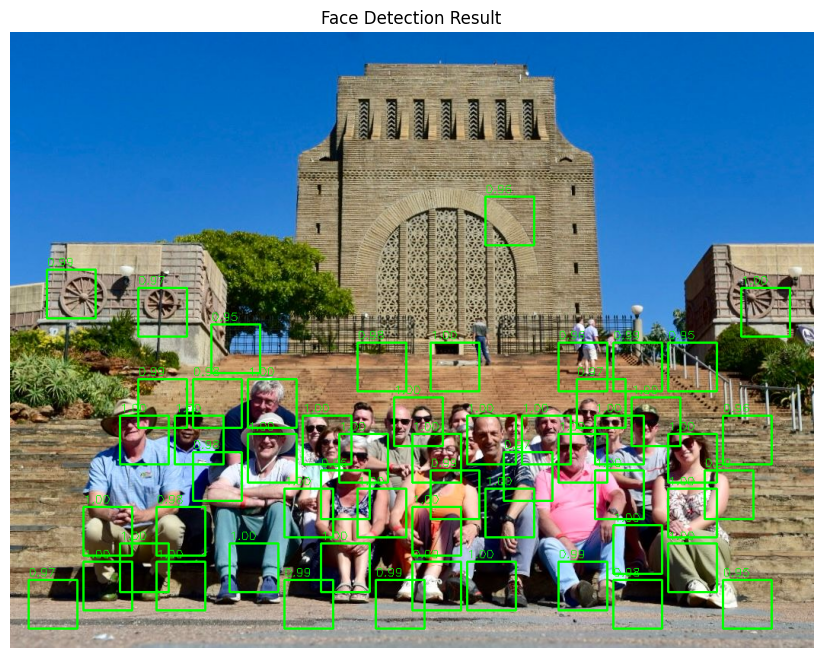

In [35]:
plt.figure(figsize=(12, 8))
plt.imshow(result_img)
plt.title("Face Detection Result")
plt.axis("off")
plt.show()

## Resultaat opslaan

In [36]:
cv2.imwrite(OUTPUT_IMAGE_PATH, cv2.cvtColor(result_img, cv2.COLOR_RGB2BGR))
print("Output opgeslagen in:", OUTPUT_IMAGE_PATH)

Output opgeslagen in: outputs/detected_faces.jpg


## Besluit 
Dit notebook is de **main application** van het project, omdat het een getraind model gebruiken om gezichten te detecteren in een grotere afbeelding. Het combineert alle onderdelen van het project:
- het voert end-to-end detectie uit 
- het visualiseert en bewaart het eindresultaat
- 
Daarmee wordt het project een pipeline met een gestructureerde flow in onze huidige implementatie:
- training van een binaire classifier, dit met foto's met gezichten en zonder gezichten
- Dan gebruik ik dat model op een grotere afbeelding via een sliding window.
- Elk venster krijgt een kansscore en vensters met hoge score worden als kandidaat-detecties opgeslagen.
- Omdat meerdere vensters vaak hetzelfde gezicht overlappen,  pas ik Non-Maximum Suppression toe zodat enkel de sterkste bounding box per gezicht behouden blijft.

Mogelijke optimalisaties en uitbreidingen:

• multi-scale sliding window gebruiken
• data augmentation toevoegen
• transfer learning toepassen, bijvoorbeeld MobileNetV2
